<a href="https://colab.research.google.com/github/BibhusanSilwal/Cricket-Score-Prediction/blob/main/23048642_Bibhusan_Silwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  T20 First Innings Score Prediction
This notebook predicts the **final first-innings score** using mid-innings (12 overs) data.


## 1. Install & Import Dependencies

In [1]:

!pip install datasets scikit-learn xgboost pandas matplotlib seaborn

import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint
import warnings
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset from Hugging Face

In [2]:

dataset = load_dataset("Valarmathy/CricketData")
df = dataset['train'].to_pandas()

print(f"Dataset shape: {df.shape}")
print(df.columns.tolist())


README.md:   0%|          | 0.00/251 [00:00<?, ?B/s]

raw/ball_by_ball_it20.csv:   0%|          | 0.00/72.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/425119 [00:00<?, ? examples/s]

Dataset shape: (425119, 35)
['Unnamed: 0', 'Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'Innings', 'Over', 'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs', 'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket', 'Method', 'Player Out', 'Innings Runs', 'Innings Wickets', 'Target Score', 'Runs to Get', 'Balls Remaining', 'Winner', 'Chased Successfully', 'Total Batter Runs', 'Total Non Striker Runs', 'Batter Balls Faced', 'Non Striker Balls Faced', 'Player Out Runs', 'Player Out Balls Faced', 'Bowler Runs Conceded', 'Valid Ball']


## 3️. Filter First Innings Data

In [3]:

df_first_innings = df[df['Innings'] == 1].copy()


## 4. Feature Engineering: Balls Played

In [4]:

df_first_innings['balls_played'] = df_first_innings['Over'] * 6 + df_first_innings['Ball']


## 5️. Define Mid-Innings Point (12 Overs)

In [5]:

mid_over = 12
mid_balls = mid_over * 6


## 6️. Encode Categorical Variables

In [6]:

venue_le = LabelEncoder()
team_le = LabelEncoder()

df_first_innings['venue_encoded'] = venue_le.fit_transform(df_first_innings['Venue'])
df_first_innings['team_encoded'] = team_le.fit_transform(df_first_innings['Bat First'])


## 7️. Aggregate Mid-Innings Features Per Match

In [7]:

mid_data = []
final_scores = []

for match_id, group in df_first_innings.groupby('Match ID'):
    group = group.sort_values(['Over', 'Ball'])
    mid_group = group[group['balls_played'] <= mid_balls]

    if len(mid_group) > 0:
        runs_so_far = mid_group['Innings Runs'].iloc[-1]
        wickets_so_far = mid_group['Innings Wickets'].iloc[-1]
        balls_so_far = mid_group['balls_played'].iloc[-1]

        venue_code = group['venue_encoded'].iloc[0]
        team_code = group['team_encoded'].iloc[0]

        mid_data.append({
            'match_id': match_id,
            'runs_so_far': runs_so_far,
            'wickets_so_far': wickets_so_far,
            'balls_so_far': balls_so_far,
            'venue_code': venue_code,
            'team_code': team_code
        })

        final_scores.append(group['Innings Runs'].max())


## 8️. Create Final Modeling Dataset

In [8]:

modeling_df = pd.DataFrame(mid_data)
modeling_df['final_score'] = final_scores


print(f"Modeling DF shape: {modeling_df.shape}")

Modeling DF shape: (1842, 7)


## 9. Exploratory Data Analysis


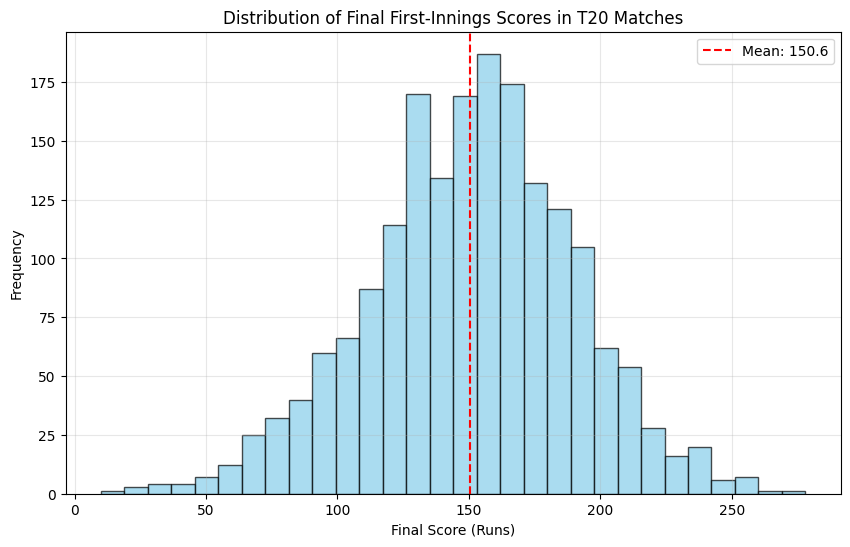

Mean Final Score: 150.6
Median Final Score: 152.0
Std Dev: 39.2


In [ ]:
#Graph 1 - Histogram of Final First-Innings Scores
plt.figure(figsize=(10, 6))
plt.hist(modeling_df['final_score'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Distribution of Final First-Innings Scores in T20 Matches')
plt.xlabel('Final Score (Runs)')
plt.ylabel('Frequency')
plt.axvline(modeling_df['final_score'].mean(), color='red', linestyle='--', label=f'Mean: {modeling_df["final_score"].mean():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary stats
print(f"Mean Final Score: {modeling_df['final_score'].mean():.1f}")
print(f"Median Final Score: {modeling_df['final_score'].median():.1f}")
print(f"Std Dev: {modeling_df['final_score'].std():.1f}")

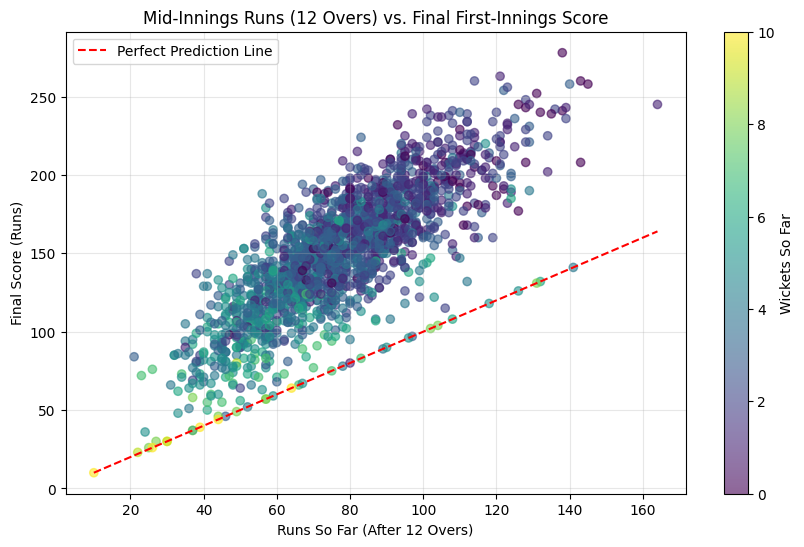

Correlation (Runs So Far vs. Final Score): 0.802


In [ ]:
# Graph 2 - Scatter Plot: Runs So Far vs. Final Score
plt.figure(figsize=(10, 6))
scatter = plt.scatter(modeling_df['runs_so_far'], modeling_df['final_score'], alpha=0.6, c=modeling_df['wickets_so_far'], cmap='viridis')
plt.colorbar(scatter, label='Wickets So Far')
plt.title('Mid-Innings Runs (12 Overs) vs. Final First-Innings Score')
plt.xlabel('Runs So Far (After 12 Overs)')
plt.ylabel('Final Score (Runs)')
plt.plot([modeling_df['runs_so_far'].min(), modeling_df['runs_so_far'].max()],
         [modeling_df['runs_so_far'].min(), modeling_df['runs_so_far'].max()], 'r--', label='Perfect Prediction Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Correlation
corr_runs_final = modeling_df['runs_so_far'].corr(modeling_df['final_score'])
print(f"Correlation (Runs So Far vs. Final Score): {corr_runs_final:.3f}")

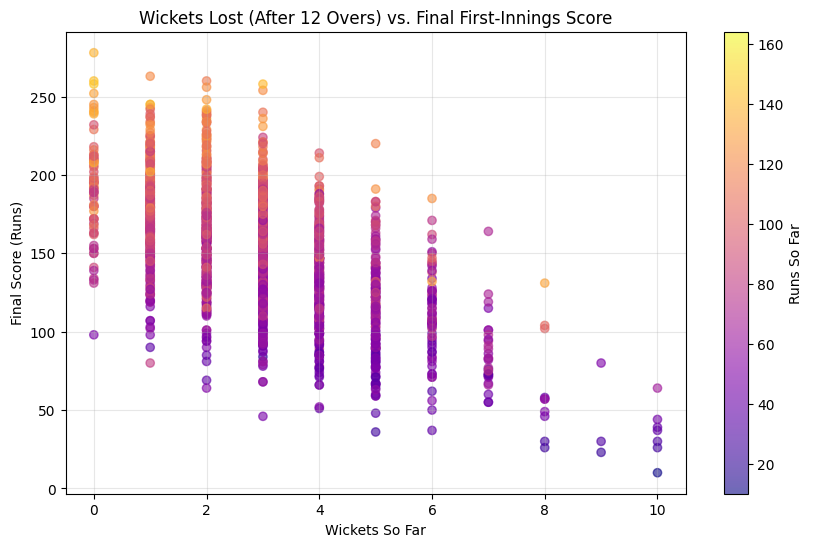

Correlation (Wickets So Far vs. Final Score): -0.608


In [ ]:
# Graph 3 - Scatter Plot: Wickets So Far vs. Final Score
plt.figure(figsize=(10, 6))
scatter = plt.scatter(modeling_df['wickets_so_far'], modeling_df['final_score'], alpha=0.6, c=modeling_df['runs_so_far'], cmap='plasma')
plt.colorbar(scatter, label='Runs So Far')
plt.title('Wickets Lost (After 12 Overs) vs. Final First-Innings Score')
plt.xlabel('Wickets So Far')
plt.ylabel('Final Score (Runs)')
plt.grid(True, alpha=0.3)
plt.show()

# Correlation
corr_wickets_final = modeling_df['wickets_so_far'].corr(modeling_df['final_score'])
print(f"Correlation (Wickets So Far vs. Final Score): {corr_wickets_final:.3f}")

/tmp/ipython-input-1993659862.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=venue_data, x='venue_name', y='final_score', palette='Set2')


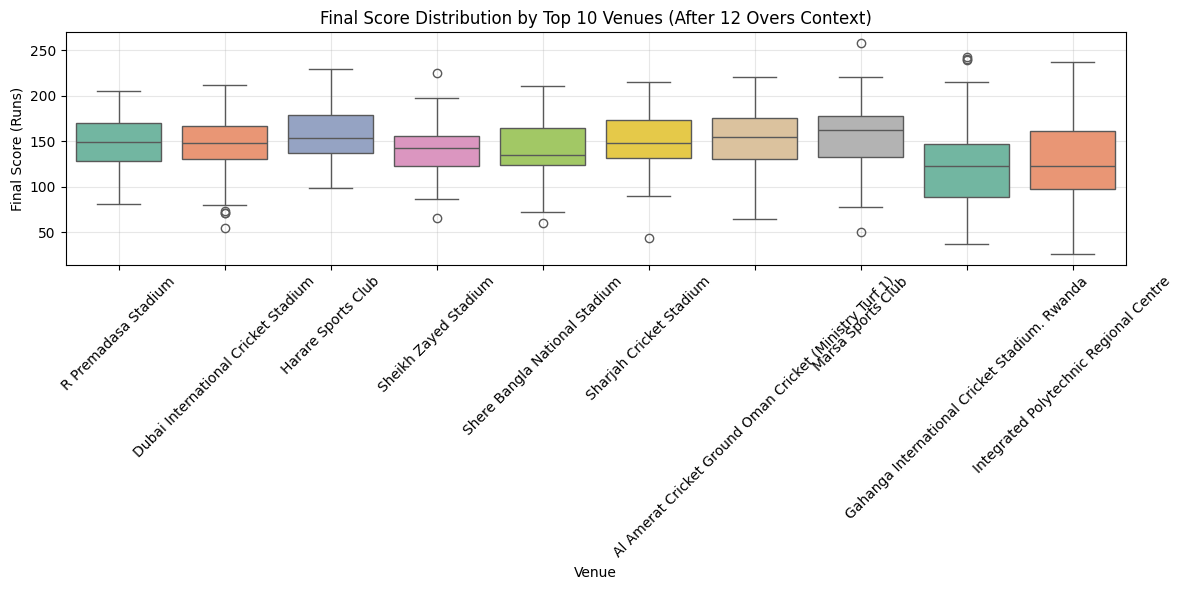

                                                     mean  count
venue_name                                                      
Al Amerat Cricket Ground Oman Cricket (Ministry...  152.4     64
Dubai International Cricket Stadium                 145.9     88
Gahanga International Cricket Stadium. Rwanda       123.9     49
Harare Sports Club                                  156.6     38
Integrated Polytechnic Regional Centre              124.8     33
Marsa Sports Club                                   157.0     48
R Premadasa Stadium                                 149.1     33
Sharjah Cricket Stadium                             149.5     31
Sheikh Zayed Stadium                                141.0     44
Shere Bangla National Stadium                       141.7     53


In [ ]:
#  Graph 4 - Box Plot: Final Score by Top 10 Venues
# Get top 10 venues by frequency
top_venues = modeling_df['venue_code'].value_counts().head(10).index
venue_names = {code: venue_le.inverse_transform([code])[0] for code in top_venues}  # Decode venue names

venue_data = modeling_df[modeling_df['venue_code'].isin(top_venues)].copy()
venue_data['venue_name'] = venue_data['venue_code'].map(venue_names)

plt.figure(figsize=(12, 6))
sns.boxplot(data=venue_data, x='venue_name', y='final_score', palette='Set2')
plt.title('Final Score Distribution by Top 10 Venues (After 12 Overs Context)')
plt.xlabel('Venue')
plt.ylabel('Final Score (Runs)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Average scores by venue
print(venue_data.groupby('venue_name')['final_score'].agg(['mean', 'count']).round(1))

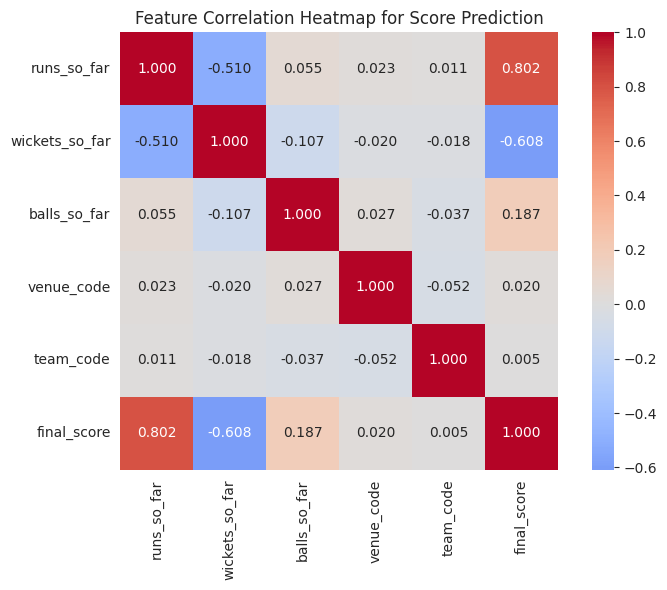

In [ ]:
# Cell 7: Graph 5 - Correlation Heatmap of Features
features = ['runs_so_far', 'wickets_so_far', 'balls_so_far', 'venue_code', 'team_code', 'final_score']
corr_matrix = modeling_df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.3f')
plt.title('Feature Correlation Heatmap for Score Prediction')
plt.tight_layout()
plt.show()

## 10. Train-Test Split

In [9]:
# Features
feature_cols = ['runs_so_far', 'wickets_so_far', 'venue_code', 'team_code',
               ]
X = modeling_df[feature_cols]
y = modeling_df['final_score']

# Stratified split by run_rate_mid bins
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.cut(modeling_df['runs_so_far'], bins=5)
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1473, 4), Test: (369, 4)


## 11. Model Training


In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred_lr = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.3f}")

Linear Regression Results
-------------------------
MAE  : 17.54
RMSE : 22.63
R²   : 0.671


In [12]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.3f}")

Random Forest Results
---------------------
MAE  : 18.82
RMSE : 23.93
R²   : 0.632


In [14]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.3f}")

XGBoost Results
----------------
MAE  : 19.97
RMSE : 25.48
R²   : 0.583


## 12. Model Tuning

In [16]:
modeling_df['run_rate_mid'] = modeling_df['runs_so_far'] / (modeling_df['balls_so_far'] / 6)
modeling_df['pressure_index'] = modeling_df['wickets_so_far'] / (modeling_df['runs_so_far'] + 1)
modeling_df['projected_remaining'] = 8 * modeling_df['run_rate_mid']

In [17]:
# Features
feature_cols = ['runs_so_far', 'wickets_so_far', 'venue_code', 'team_code',
                'run_rate_mid', 'pressure_index', 'projected_remaining']
X = modeling_df[feature_cols]
y = modeling_df['final_score']

# Stratified split by run_rate_mid bins
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.cut(modeling_df['run_rate_mid'], bins=5)
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1473, 7), Test: (369, 7)


In [18]:
best_params = {'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8}
tuned_xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    **best_params,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'colsample_bytree': 0.8,
    'seed': 42
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

evals = [(dtrain, 'train'), (dtest, 'eval')]
bst = xgb.train(
    tuned_xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=10,
    verbose_eval=False
)

y_pred_tuned = bst.predict(dtest)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned XGBoost: MAE={mae_tuned:.2f}, RMSE={rmse_tuned:.2f}, R²={r2_tuned:.3f}")


cv_scores = cross_val_score(
    xgb.XGBRegressor(**{k: v for k, v in tuned_xgb_params.items() if k not in ['objective', 'eval_metric']}, random_state=42),
    X_train, y_train, cv=5, scoring='r2'
)
print(f"5-Fold CV R²: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Tuned XGBoost: MAE=16.41, RMSE=21.57, R²=0.679
5-Fold CV R²: 0.709 (+/- 0.034)


## 13. Model Comparison


In [19]:


comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Untuned XGBoost", "Tuned XGBoost"],
    "MAE": [lr_mae, rf_mae, xgb_mae, mae_tuned],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse, rmse_tuned],
    "R2 Score": [lr_r2, rf_r2, xgb_r2, r2_tuned]
})

display(comparison)

print(f"Tuned XGBoost 5-Fold CV R²: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

,Model,MAE,RMSE,R2 Score
0,Linear Regression,17.544426,22.627885,0.671138
1,Random Forest,18.817512,23.931877,0.632142
2,Untuned XGBoost,19.970800,25.478544,0.583058
3,Tuned XGBoost,16.408007,21.571502,0.678594


Tuned XGBoost 5-Fold CV R²: 0.709 (+/- 0.034)


## 14. Actual vs Predicted Plot


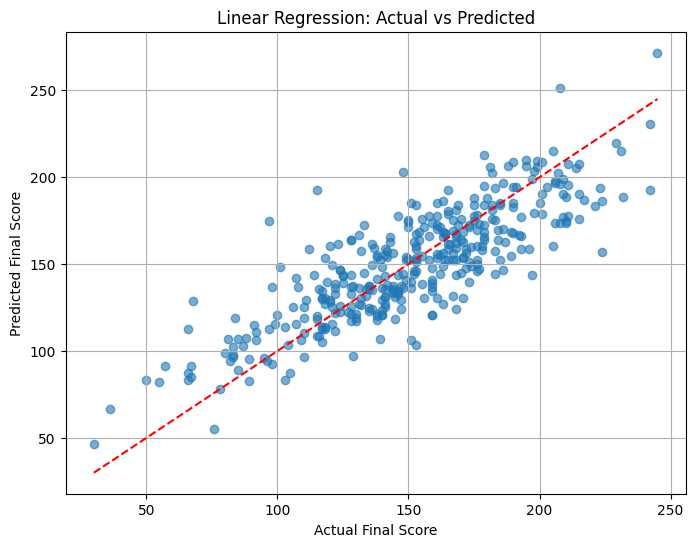

In [ ]:
# Linear Regression predictions
y_pred_lr = lr_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


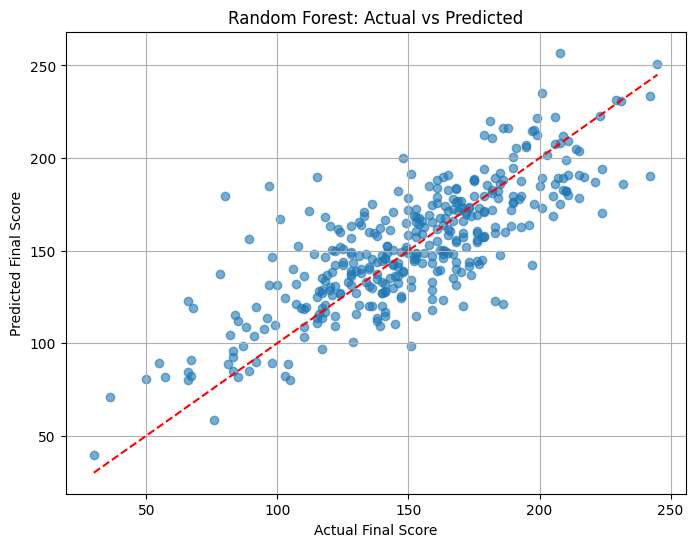

In [ ]:

y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.show()


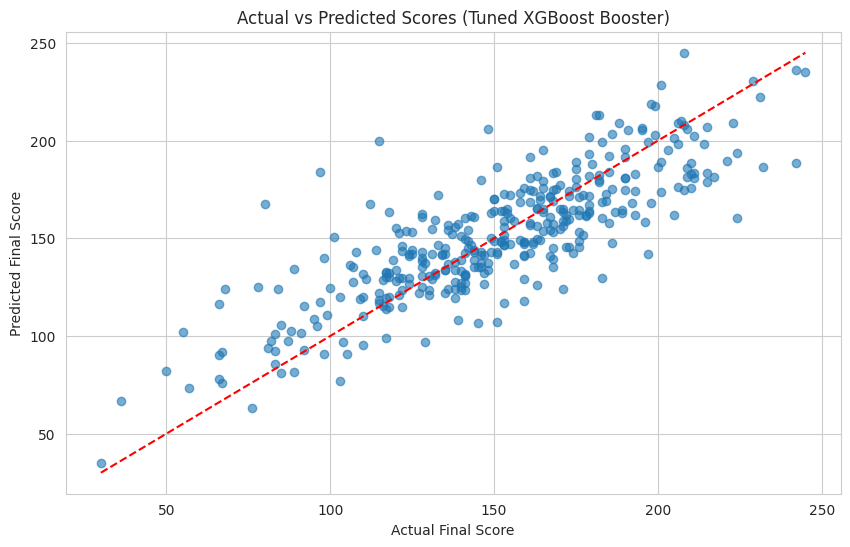

In [ ]:
y_pred_best = bst.predict(dtest)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Scores (Tuned XGBoost Booster)')
plt.grid(True)
plt.show()

## 15. Residual Analysis

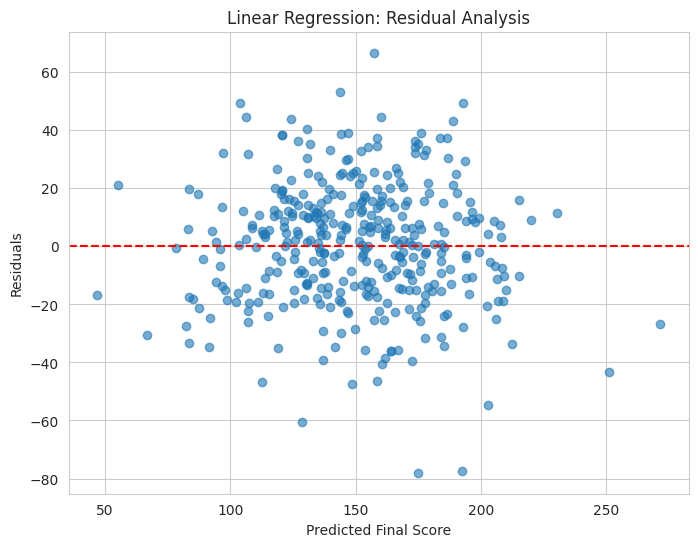

In [ ]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Final Score")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Analysis")
plt.grid(True)
plt.show()


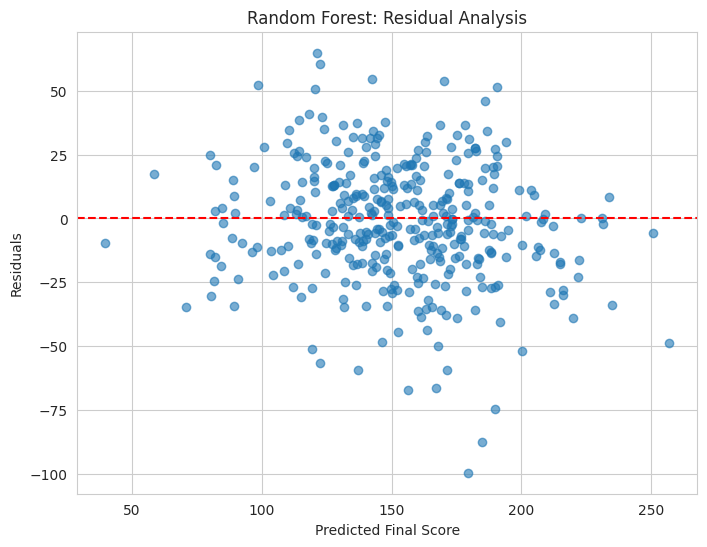

In [ ]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Final Score")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Analysis")
plt.grid(True)
plt.show()


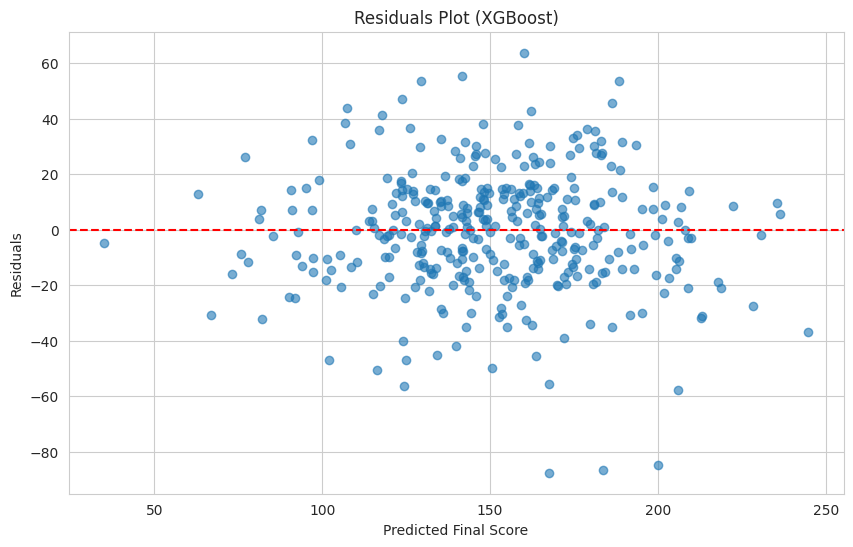

In [ ]:
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Final Score')
plt.ylabel('Residuals')
plt.title('Residuals Plot (XGBoost)')
plt.grid(True)
plt.show()


## 16. Feature Importance

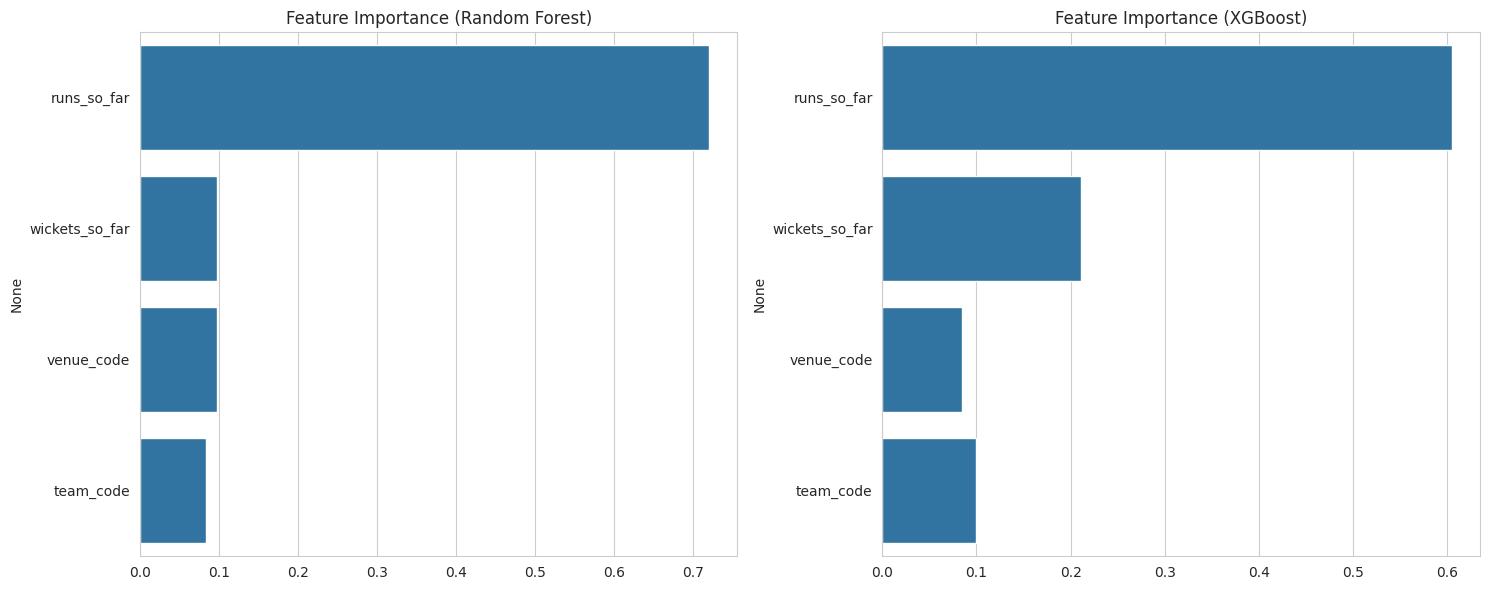

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(
    x=rf_model.feature_importances_,
    y=X.columns,
    ax=axes[0]
)
axes[0].set_title('Feature Importance (Random Forest)')

sns.barplot(
    x=xgb_model.feature_importances_,
    y=X.columns,
    ax=axes[1]
)
axes[1].set_title('Feature Importance (XGBoost)')

plt.tight_layout()
plt.show()


## 17. Model Comparison

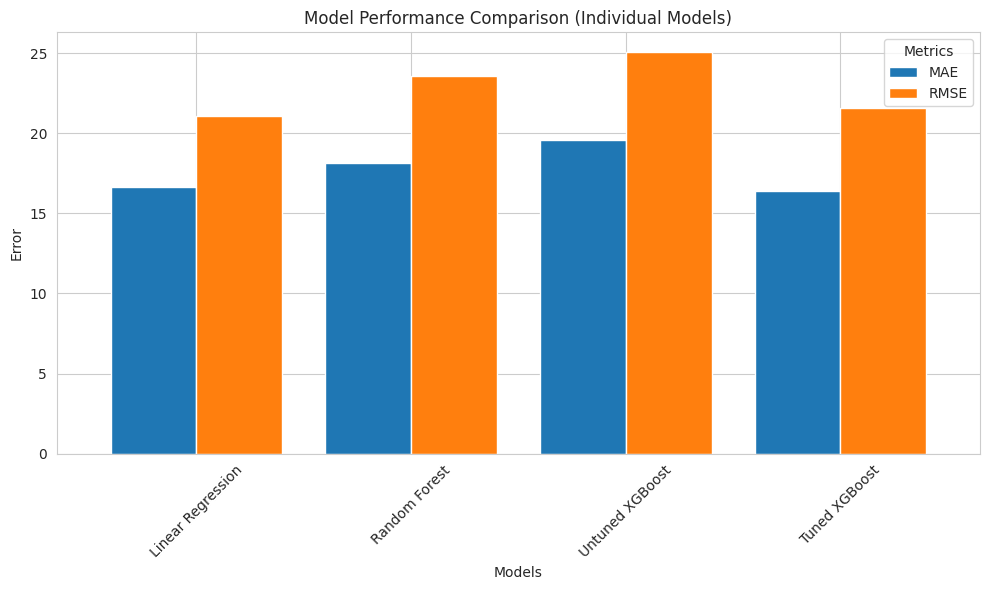

In [ ]:

comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('Model Performance Comparison (Individual Models)')

plt.ylabel('Error')

plt.xlabel('Models')

plt.xticks(rotation=45)

plt.legend(title='Metrics')

plt.tight_layout()

plt.show()



## 18. Model Prediction


In [25]:

import numpy as np
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

def predict_final_score(runs_so_far, wickets_so_far, balls_so_far=72, venue_name='Dambulla', team_name='Sri Lanka', models_dict=None, venue_le=None, team_le=None):
    """
    Predict final score with fallback for unseen venues/teams.
    Models use only 4 features: runs_so_far, wickets_so_far, venue_code, team_code.
    """
    # Safe transform with fallback (default 0 for unknown)
    try:
        venue_code = venue_le.transform([venue_name])[0]
    except (ValueError, KeyError):
        print(f"Warning: Unseen venue '{venue_name}' – Using default code 0")
        venue_code = 0

    try:
        team_code = team_le.transform([team_name])[0]
    except (ValueError, KeyError):
        print(f"Warning: Unseen team '{team_name}' – Using default code 0")
        team_code = 0


    input_features = np.array([[runs_so_far, wickets_so_far, venue_code, team_code]])

    # Predict with Linear
    lr_pred = models_dict['lr'].predict(input_features)[0]

    # Predict with Random Forest
    rf_pred = models_dict['rf'].predict(input_features)[0]

    # XGBoost prediction
    if isinstance(models_dict['xgb'], xgb.Booster):
        d_input = xgb.DMatrix(input_features)
        xgb_pred = models_dict['xgb'].predict(d_input)[0]
    else:
        xgb_pred = models_dict['xgb'].predict(input_features)[0]

    avg_pred = np.mean([lr_pred, rf_pred, xgb_pred])

    return {
        'Linear (4 Feats)': round(lr_pred, 1),
        'Random Forest (4 Feats)': round(rf_pred, 1),
        'XGBoost (4 Feats)': round(xgb_pred, 1),
        'Ensemble Avg': round(avg_pred, 1)
    }


models_dict = {
    'lr': lr_model,
    'rf': rf_model,
    'xgb': xgb_model
}

# Manual mappings (same as before)
venue_mappings = {
    'Rangiri Dambulla International Stadium': 'Dambulla International Stadium',
    'Dubai International Cricket Stadium': 'Dubai International Cricket Stadium'
}
team_mappings = {
    'Sri Lanka': 'Sri Lanka',
    'Afghanistan': 'Afghanistan'
}

# Game 1: SL vs PAK 3rd T20I, Jan 11, 2026 (Actual: 160/6)
print("=== Game 1: Sri Lanka vs Pakistan (3rd T20I, Jan 11, 2026) ===")
print("Mid-12 Overs: 160 runs / 6 wickets | Venue: Dambulla | Team: Sri Lanka")
print("Actual Final: 160")
v1 = venue_mappings.get('Rangiri Dambulla International Stadium', 'Dambulla International Stadium')
t1 = team_mappings.get('Sri Lanka', 'Sri Lanka')
pred1 = predict_final_score(160, 6, venue_name=v1, team_name=t1, models_dict=models_dict, venue_le=venue_le, team_le=team_le)
print("Predictions:", pred1)
print(f"Ensemble Avg Error: {abs(160 - pred1['Ensemble Avg']):.1f} runs")
print()

# Game 2: AFG vs WI 1st T20I, Jan 19, 2026 (Actual: 181/3)
print("=== Game 2: Afghanistan vs West Indies (1st T20I, Jan 19, 2026) ===")
print("Mid-12 Overs: 100 runs / 2 wickets | Venue: Dubai | Team: Afghanistan")
print("Actual Final: 181")
v2 = venue_mappings.get('Dubai International Cricket Stadium', 'Dubai International Cricket Stadium')
t2 = team_mappings.get('Afghanistan', 'Afghanistan')
pred2 = predict_final_score(100, 2, venue_name=v2, team_name=t2, models_dict=models_dict, venue_le=venue_le, team_le=team_le)
print("Predictions:", pred2)
print(f"Ensemble Avg Error: {abs(181 - pred2['Ensemble Avg']):.1f} runs")
print()

# Game 3: SL vs PAK 1st T20I, Jan 7, 2026 (Actual: 128 all out)
print("=== Game 3: Sri Lanka vs Pakistan (1st T20I, Jan 7, 2026) ===")
print("Mid-12 Overs: 85 runs / 5 wickets | Venue: Dambulla | Team: Sri Lanka")
print("Actual Final: 128")
v3 = venue_mappings.get('Rangiri Dambulla International Stadium', 'Dambulla International Stadium')
t3 = team_mappings.get('Sri Lanka', 'Sri Lanka')
pred3 = predict_final_score(85, 5, venue_name=v3, team_name=t3, models_dict=models_dict, venue_le=venue_le, team_le=team_le)
print("Predictions:", pred3)
print(f"Ensemble Avg Error: {abs(128 - pred3['Ensemble Avg']):.1f} runs")
print()

# Summary Table
summary = pd.DataFrame({
    'Game': ['SL vs PAK 3rd', 'AFG vs WI 1st', 'SL vs PAK 1st'],
    'Actual Final': [160, 181, 128],
    'Linear Pred': [pred1['Linear (4 Feats)'], pred2['Linear (4 Feats)'], pred3['Linear (4 Feats)']],
    'RF Pred': [pred1['Random Forest (4 Feats)'], pred2['Random Forest (4 Feats)'], pred3['Random Forest (4 Feats)']],
    'XG Pred': [pred1['XGBoost (4 Feats)'], pred2['XGBoost (4 Feats)'], pred3['XGBoost (4 Feats)']],
    'Ensemble Avg': [pred1['Ensemble Avg'], pred2['Ensemble Avg'], pred3['Ensemble Avg']],
    'Avg Error': [abs(160 - pred1['Ensemble Avg']), abs(181 - pred2['Ensemble Avg']), abs(128 - pred3['Ensemble Avg'])]
})
print("\nSummary Table (All Models with 4 Features):")
print(summary.round(1))

=== Game 1: Sri Lanka vs Pakistan (3rd T20I, Jan 11, 2026) ===
Mid-12 Overs: 160 runs / 6 wickets | Venue: Dambulla | Team: Sri Lanka
Actual Final: 160
Predictions: {'Linear (4 Feats)': np.float64(233.5), 'Random Forest (4 Feats)': np.float64(147.6), 'XGBoost (4 Feats)': np.float32(146.3), 'Ensemble Avg': np.float64(175.8)}
Ensemble Avg Error: 15.8 runs

=== Game 2: Afghanistan vs West Indies (1st T20I, Jan 19, 2026) ===
Mid-12 Overs: 100 runs / 2 wickets | Venue: Dubai | Team: Afghanistan
Actual Final: 181
Predictions: {'Linear (4 Feats)': np.float64(185.8), 'Random Forest (4 Feats)': np.float64(188.8), 'XGBoost (4 Feats)': np.float32(176.4), 'Ensemble Avg': np.float64(183.6)}
Ensemble Avg Error: 2.6 runs

=== Game 3: Sri Lanka vs Pakistan (1st T20I, Jan 7, 2026) ===
Mid-12 Overs: 85 runs / 5 wickets | Venue: Dambulla | Team: Sri Lanka
Actual Final: 128
Predictions: {'Linear (4 Feats)': np.float64(145.2), 'Random Forest (4 Feats)': np.float64(149.4), 'XGBoost (4 Feats)': np.float32(13